# Overfitting and underfitting

### Seen, rather than described

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | What overfitting looks like on a chart rather than in a definition, how to spot it from two numbers, what the bias-variance tradeoff means concretely, and how more data changes the picture |
| **You should already know** | [Linear regression](../../02-regression/01-linear-regression/) |
| **Datasets** | UCI Bike Sharing, plus a small synthetic curve |
| **Runtime** | About a minute on a laptop CPU |
| **Next** | [01-04 Cross-validation](../04-cross-validation/) |

---

## 1. The one sentence version

**Underfitting** is a model too simple to capture the pattern. It is wrong on the
training data and wrong on new data, in the same way.

**Overfitting** is a model that learned the pattern *and* the noise. It is right
on the training data and wrong on new data, and the gap between those two is
the only warning you get.

Everything else in this notebook is that sentence, measured.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

## 2. Watching it happen

A curve with noise, and polynomials of rising degree fitted to twenty points.

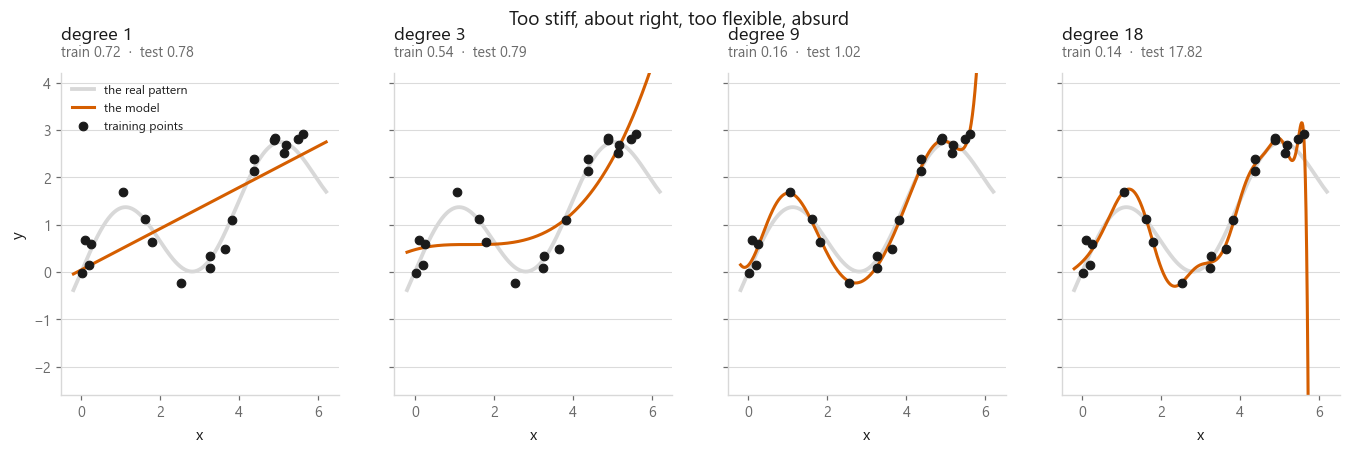

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

rng = np.random.default_rng(SEED)
truth = lambda x: np.sin(1.6 * x) + 0.35 * x

x_train = np.sort(rng.uniform(0, 6, 20))
y_train = truth(x_train) + rng.normal(0, 0.35, 20)
x_test = np.sort(rng.uniform(0, 6, 200))
y_test = truth(x_test) + rng.normal(0, 0.35, 200)

grid = np.linspace(-0.2, 6.2, 400)
degrees = [1, 3, 9, 18]

fig, axes = plt.subplots(1, 4, figsize=(15.0, 3.8), sharey=True)
for ax, degree in zip(axes, degrees):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(x_train[:, None], y_train)

    train_rmse = np.sqrt(np.mean((model.predict(x_train[:, None]) - y_train) ** 2))
    test_rmse = np.sqrt(np.mean((model.predict(x_test[:, None]) - y_test) ** 2))

    ax.plot(grid, truth(grid), color=style.RULE, lw=2.5, label="the real pattern")
    ax.plot(grid, model.predict(grid[:, None]), color=style.HIGHLIGHT, lw=2, label="the model")
    ax.scatter(x_train, y_train, s=32, c=style.INK, zorder=3, label="training points")
    ax.set_ylim(-2.6, 4.2)
    ax.set_xlabel("x")
    style.title(ax, f"degree {degree}",
                f"train {train_rmse:.2f}  ·  test {test_rmse:.2f}")

axes[0].set_ylabel("y")
axes[0].legend(fontsize=8, loc="upper left")
fig.suptitle("Too stiff, about right, too flexible, absurd",
             x=0.5, y=1.03, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-01-seeing-it.png")

Degree 1 cannot bend at all: it misses the shape entirely, and its training and
test errors are both bad. That is **underfitting**.

Degree 18 passes through almost every training point, and between them it swings
wildly to places the data never goes. Its training error is tiny and its test
error is enormous. That is **overfitting**.

Degree 3 is neither. Notice you cannot tell which is best from the training
error alone: it improves all the way across these four panels while the test
error goes to pieces.

## 3. The two numbers that matter

degree  1: train 0.720  test 0.777   <- underfitting
degree  4: train 0.250  test 0.409   <- about right
degree 20: train 0.302  test 146.102   <- overfitting
lowest training error anywhere on the curve: 0.123, at degree 13
test error at degree 20 is 357x the error at degree 4


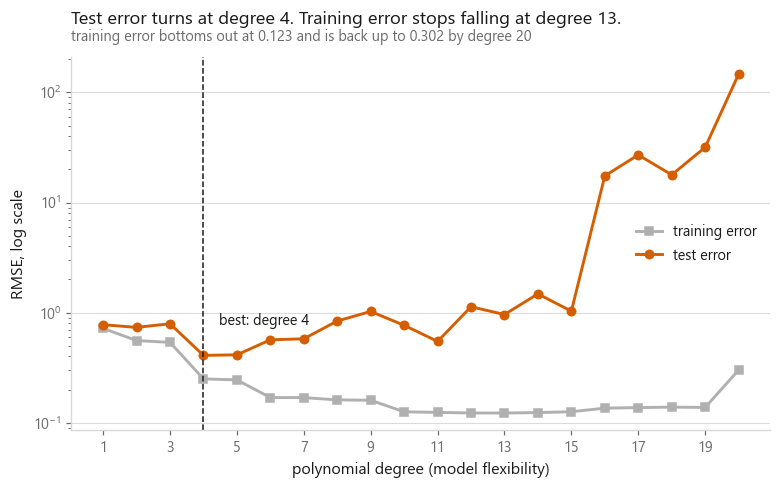

In [3]:
degrees = list(range(1, 21))
train_curve, test_curve = [], []
for degree in degrees:
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(x_train[:, None], y_train)
    train_curve.append(np.sqrt(np.mean((model.predict(x_train[:, None]) - y_train) ** 2)))
    test_curve.append(np.sqrt(np.mean((model.predict(x_test[:, None]) - y_test) ** 2)))

best = int(np.argmin(test_curve))
floor = int(np.argmin(train_curve))

fig, ax = plt.subplots(figsize=(8.2, 4.4))
ax.plot(degrees, train_curve, marker=style.MARKERS[1], color=style.NEUTRAL, label="training error")
ax.plot(degrees, test_curve, marker=style.MARKERS[0], color=style.HIGHLIGHT, label="test error")
ax.axvline(degrees[best], color=style.INK, ls="--", lw=1)
ax.annotate(f"best: degree {degrees[best]}", xy=(degrees[best], test_curve[best]),
            xytext=(10, 20), textcoords="offset points", fontsize=9.5, color=style.INK)
ax.set_yscale("log")
ax.set_xticks(degrees[::2])
ax.set_xlabel("polynomial degree (model flexibility)")
ax.set_ylabel("RMSE, log scale")
ax.legend()
style.title(
    ax,
    f"Test error turns at degree {degrees[best]}. Training error stops falling at degree {degrees[floor]}.",
    f"training error bottoms out at {train_curve[floor]:.3f} and is back up to "
    f"{train_curve[-1]:.3f} by degree {degrees[-1]}",
)
style.save(fig, FIG / "fig-02-the-curve.png")

print(f"degree  1: train {train_curve[0]:.3f}  test {test_curve[0]:.3f}   <- underfitting")
print(f"degree {degrees[best]:>2}: train {train_curve[best]:.3f}  test {test_curve[best]:.3f}   <- about right")
print(f"degree 20: train {train_curve[-1]:.3f}  test {test_curve[-1]:.3f}   <- overfitting")
print(f"lowest training error anywhere on the curve: {train_curve[floor]:.3f}, at degree {degrees[floor]}")
print(f"test error at degree 20 is {test_curve[-1] / test_curve[best]:.0f}x the error at degree {degrees[best]}")

In [4]:
# Why does the training error climb again at the top of the range? Nothing to do
# with statistics: the columns are raw powers of x, so they differ in scale by
# many orders of magnitude and the least-squares solver stops being able to
# separate them. The condition number says how badly.
from sklearn.preprocessing import StandardScaler

for degree in [degrees[floor], degrees[-1]]:
    design = PolynomialFeatures(degree).fit_transform(x_train[:, None])
    rescaled = make_pipeline(PolynomialFeatures(degree), StandardScaler(), LinearRegression())
    rescaled.fit(x_train[:, None], y_train)
    rescaled_rmse = np.sqrt(np.mean((rescaled.predict(x_train[:, None]) - y_train) ** 2))
    print(f"degree {degree:>2}: condition number {np.linalg.cond(design):.1e}   "
          f"train {train_curve[degree - 1]:.3f} as fitted, {rescaled_rmse:.3f} after rescaling the columns")

degree 13: condition number 4.8e+13   train 0.123 as fitted, 0.123 after rescaling the columns
degree 20: condition number 1.1e+21   train 0.302 as fitted, 0.041 after rescaling the columns


This chart is the single most useful diagnostic in machine learning, and it is
worth memorising its shape. It also does not do what the textbook version of it
does, and the difference is the more interesting half.

**Training error stops falling.** The textbook curve slides down to zero, and
the argument for why is sound: a degree 20 polynomial has 21 free coefficients
and only 20 points to fit, so it should be able to pass through every one of
them exactly. Mine goes down to 0.123 at degree 13 and then climbs back to
0.302 at degree 20, worse than degree 4 managed.

That is an arithmetic effect rather than a statistical one. The features here
are raw powers of x, and x runs up to 6, so the last column of the design matrix
holds enormous numbers sitting next to a column of ones. The printout above puts
the condition number at 1.1e+21, well past what double precision can resolve.
`LinearRegression` calls a least-squares driver that discards singular values
below a tolerance, so beyond that point it quietly returns something other than
the minimiser. Standardising the columns first, which changes nothing about the
space of functions the model can reach, drops the training error to 0.041 and
restores the textbook picture.

So the honest version of the claim is: **a low training error tells you nothing
on its own, and a high one does not always mean the model is too stiff.** It can
also mean the optimiser gave up. Anything you read off the far right of this
chart is measuring numerical conditioning, not flexibility.

**Test error falls, bottoms out, then rises.** That part holds. The turning
point is where the model stops learning the pattern and starts learning the
noise.

**The gap between the lines is the overfitting.** Not the height of either one,
the distance between them.

## 4. Bias and variance

The usual names for the two failure modes. Rather than define them, refit the
same model on many different training samples and watch what the predictions do.

degree  1: bias²           0.434   variance           0.048   largest prediction on the grid          2.9   bias² of the median fit     0.426
degree  4: bias²           0.096   variance           0.096   largest prediction on the grid          4.3   bias² of the median fit     0.070
degree 15: bias²     5803716.617   variance   312903481.348   largest prediction on the grid     868921.3   bias² of the median fit     4.925


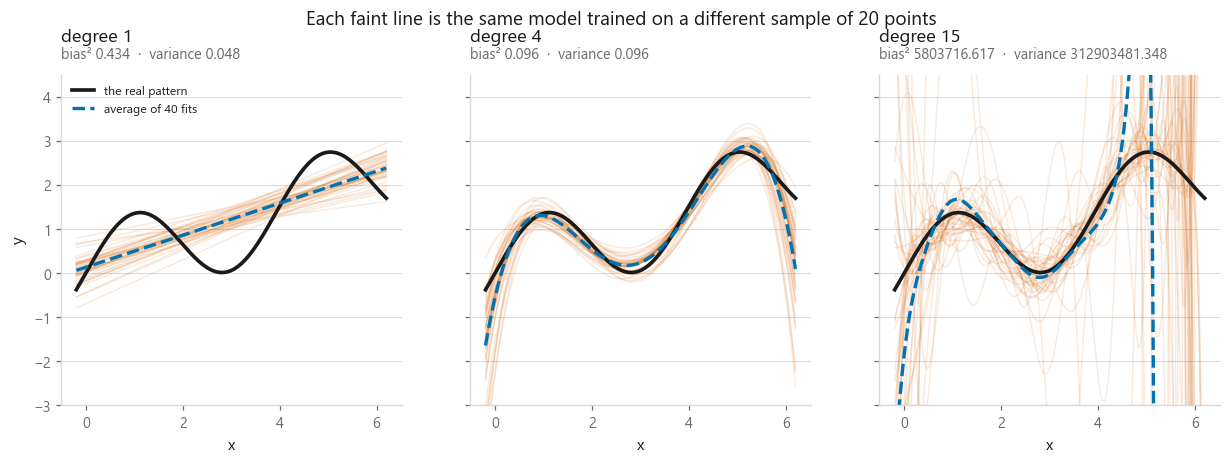

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13.6, 3.9), sharey=True)
scores = {}

for ax, degree in zip(axes, [1, 4, 15]):
    predictions = []
    for trial in range(40):
        local_rng = np.random.default_rng(trial)
        xs = np.sort(local_rng.uniform(0, 6, 20))
        ys = truth(xs) + local_rng.normal(0, 0.35, 20)
        model = make_pipeline(PolynomialFeatures(degree), LinearRegression()).fit(xs[:, None], ys)
        curve = model.predict(grid[:, None])
        predictions.append(curve)
        ax.plot(grid, curve, color=style.HIGHLIGHT, alpha=0.13, lw=1)

    predictions = np.array(predictions)
    ax.plot(grid, truth(grid), color=style.INK, lw=2.4, label="the real pattern")
    ax.plot(grid, predictions.mean(axis=0), color=style.PALETTE[0], lw=2.2, ls="--",
            label="average of 40 fits")
    ax.set_ylim(-3, 4.5)
    ax.set_xlabel("x")

    bias = np.mean((predictions.mean(axis=0) - truth(grid)) ** 2)
    variance = np.mean(predictions.var(axis=0))
    scores[degree] = (bias, variance, np.abs(predictions).max(),
                      np.mean((np.median(predictions, axis=0) - truth(grid)) ** 2))
    style.title(ax, f"degree {degree}", f"bias² {bias:.3f}  ·  variance {variance:.3f}")

axes[0].set_ylabel("y")
axes[0].legend(fontsize=8, loc="upper left")
fig.suptitle("Each faint line is the same model trained on a different sample of 20 points",
             x=0.5, y=1.03, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-03-bias-variance.png")

for degree, (bias, variance, extreme, median_bias) in scores.items():
    print(f"degree {degree:>2}: bias² {bias:15.3f}   variance {variance:15.3f}   "
          f"largest prediction on the grid {extreme:12.1f}   "
          f"bias² of the median fit {median_bias:9.3f}")

**Degree 1: high bias, low variance.** The forty fits sit almost on top of each
other (the model is stable), and all of them are wrong in the same way. Its
average is nowhere near the truth. It is consistently mistaken.

**Degree 4 balances them**, which is what "the bias-variance tradeoff" means. Its
bias² of 0.096 is the lowest of the three and its variance is the same size.

**Degree 15 does not have low bias, and I expected it to.** The textbook version
of this panel says a very flexible model has low bias and high variance: any one
fit is unreliable, but the fits average out to the truth, so the model is not
systematically wrong. The variance half of that is right and then some, at
312903481.348. The bias half is not. Degree 15 prints bias² 5803716.617 against
0.434 for degree 1, which makes the most flexible model in the figure the most
systematically wrong one, by seven orders of magnitude. The dashed "average of 40
fits" line does not track the real pattern. It is off the top of the axes for
most of the panel.

The mechanism is that squared bias averages the fits, and an average has no
defence against one bad member. The largest prediction anywhere in that panel is
868921.3, from a single fit, and a handful of others are not far behind. Those
few drag the mean curve with them, mostly near the ends of the range where a
degree 15 polynomial has the least data holding it down. Take the median of the
forty fits instead of the mean and the same quantity comes out at 4.925: still
the worst of the three, but a different order of magnitude.

So the honest reading is that "low bias, high variance" describes a high variance
model whose errors happen to be symmetric. When the errors are heavy tailed, as
they are here, the flexible model is unstable *and* biased, and the two are the
same fact seen twice. High bias is being wrong the same way every time. High
variance is being wrong a different way every time. Degree 15 manages both.

## 5. More data changes where the line is

The overfitting threshold is not a property of the model alone. It depends on how
much data the model has to justify its flexibility.

n          15     30     60     120    400
degree                                    
1        0.783  0.766  0.760  0.757  0.757
3        0.749  0.729  0.672  0.653  0.648
6        0.547  0.415  0.378  0.370  0.363
12      14.233  0.413  0.388  0.393  0.362
18      26.305  0.435  0.432  0.423  0.427

at 400 points the best degree is 12 at 0.362; degree 18 is 0.427, 18% worse
degree 18 went from 26.305 at 15 points to 0.427 at 400


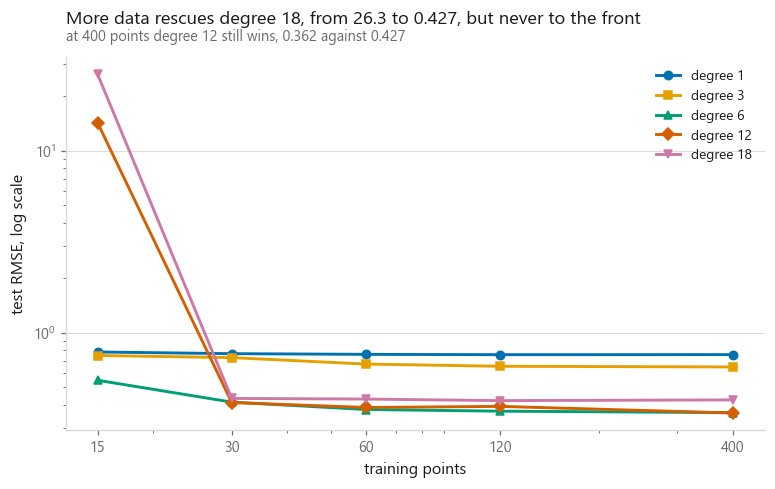

In [6]:
sizes = [15, 30, 60, 120, 400]
records = []
for n in sizes:
    local_rng = np.random.default_rng(SEED)
    xs = np.sort(local_rng.uniform(0, 6, n))
    ys = truth(xs) + local_rng.normal(0, 0.35, n)
    for degree in [1, 3, 6, 12, 18]:
        model = make_pipeline(PolynomialFeatures(degree), LinearRegression()).fit(xs[:, None], ys)
        records.append({"n": n, "degree": degree,
                        "test RMSE": np.sqrt(np.mean((model.predict(x_test[:, None]) - y_test) ** 2))})
frame = pd.DataFrame(records)
table = frame.pivot_table(index="degree", columns="n", values="test RMSE")

fig, ax = plt.subplots(figsize=(8.2, 4.4))
for i, degree in enumerate(sorted(frame.degree.unique())):
    subset = frame[frame.degree == degree]
    ax.plot(subset["n"], subset["test RMSE"], marker=style.MARKERS[i % len(style.MARKERS)],
            color=style.PALETTE[i], label=f"degree {degree}")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xticks(sizes, [str(s) for s in sizes])
ax.set_xlabel("training points")
ax.set_ylabel("test RMSE, log scale")
ax.legend(fontsize=9)
style.title(
    ax,
    f"More data rescues degree 18, from {table.loc[18, sizes[0]]:.1f} "
    f"to {table.loc[18, sizes[-1]]:.3f}, but never to the front",
    f"at {sizes[-1]} points degree {table[sizes[-1]].idxmin()} still wins, "
    f"{table[sizes[-1]].min():.3f} against {table.loc[18, sizes[-1]]:.3f}",
)
style.save(fig, FIG / "fig-04-more-data.png")

print(table.round(3).to_string())

largest = sizes[-1]
winner = table[largest].idxmin()
print(f"\nat {largest} points the best degree is {winner} at {table[largest].min():.3f}; "
      f"degree 18 is {table.loc[18, largest]:.3f}, "
      f"{100 * (table.loc[18, largest] / table[largest].min() - 1):.0f}% worse")
print(f"degree 18 went from {table.loc[18, sizes[0]]:.3f} at {sizes[0]} points "
      f"to {table.loc[18, largest]:.3f} at {largest}")

At 15 points, degree 18 is a disaster, 26.305. At 400 points it is survivable,
0.427, and I wrote in an earlier draft that the extra flexibility therefore costs
nothing. The table says otherwise. At 400 points degree 12 comes in at 0.362 and
degree 6 at 0.363, so degree 18 is still 18% worse than the best on offer, and it
stays behind both of them at every sample size from 30 upwards.

More data did not make the extra flexibility free. It made it affordable. The
penalty fell from catastrophic to eighteen per cent, which is the difference
between a model you cannot ship and a model you would rather not ship. Driving
that last eighteen per cent out takes regularisation rather than data, which is
what [ridge](../../02-regression/04-ridge-regression/) is for: pay for unused
flexibility in bias instead of in variance.

Degree 1 does not improve at all with more data, 0.783 at 15 points and 0.757 at
400. No amount of evidence fixes a model that structurally cannot represent the
pattern. **More data cures variance, not bias.**

## 6. On real data

The same story, on Bike Sharing, with tree depth as the flexibility dial.

depth   12: train   34.1  held out   57.8
depth none: train    0.3  held out   61.2  <- perfect on training, worse on new data


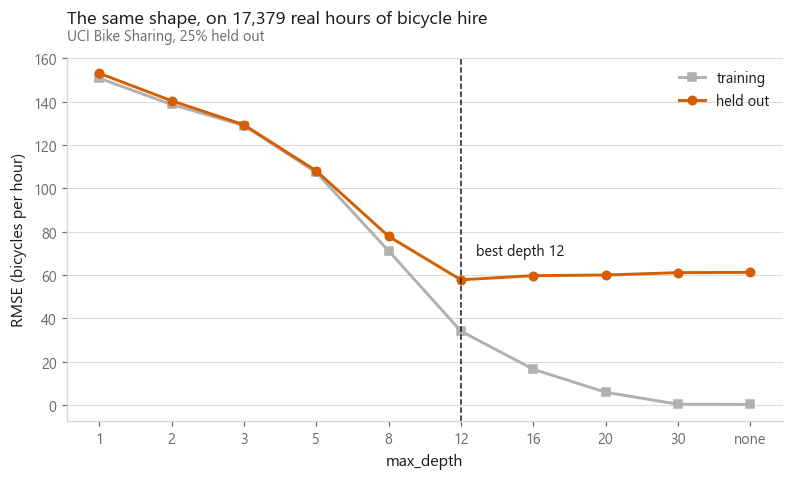

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

X_bike, y_bike = datasets.bike_sharing()
X_tr, X_te, y_tr, y_te = train_test_split(X_bike.values, y_bike.values,
                                          test_size=0.25, random_state=SEED)

depths = [1, 2, 3, 5, 8, 12, 16, 20, 30, None]
labels = [str(d) if d else "none" for d in depths]
train_scores, test_scores = [], []
for depth in depths:
    tree = DecisionTreeRegressor(max_depth=depth, random_state=SEED).fit(X_tr, y_tr)
    train_scores.append(np.sqrt(np.mean((tree.predict(X_tr) - y_tr) ** 2)))
    test_scores.append(np.sqrt(np.mean((tree.predict(X_te) - y_te) ** 2)))

positions = np.arange(len(depths))
best = int(np.argmin(test_scores))

fig, ax = plt.subplots(figsize=(8.4, 4.3))
ax.plot(positions, train_scores, marker=style.MARKERS[1], color=style.NEUTRAL, label="training")
ax.plot(positions, test_scores, marker=style.MARKERS[0], color=style.HIGHLIGHT, label="held out")
ax.axvline(best, color=style.INK, ls="--", lw=1)
ax.annotate(f"best depth {labels[best]}", xy=(best, test_scores[best]), xytext=(10, 16),
            textcoords="offset points", fontsize=9.5, color=style.INK)
ax.set_xticks(positions, labels)
ax.set_xlabel("max_depth")
ax.set_ylabel("RMSE (bicycles per hour)")
ax.legend()
style.title(ax, "The same shape, on 17,379 real hours of bicycle hire",
            "UCI Bike Sharing, 25% held out")
style.save(fig, FIG / "fig-05-real-data.png")

print(f"depth {labels[best]:>4}: train {train_scores[best]:6.1f}  held out {test_scores[best]:6.1f}")
print(f"depth none: train {train_scores[-1]:6.1f}  held out {test_scores[-1]:6.1f}  "
      f"<- perfect on training, worse on new data")

## How to spot it, and what to do

**Spotting it** takes two numbers: the error on data the model trained on, and
the error on data it has not seen. If the first is much better than the second,
you are overfitting. If both are bad, you are underfitting.

**If you are overfitting**, in rough order of what to try first:

1. Get more data. It is the only fix with no downside.
2. Reduce flexibility: shallower trees, fewer features, lower polynomial degree.
3. Add regularisation: [Ridge](../../02-regression/04-ridge-regression/) or
   [Lasso](../../02-regression/05-lasso-regression/) for linear models, dropout
   and weight decay for networks.
4. Stop training earlier, for anything iterative.
5. Average several models: [bagging](../../04-ensembles/01-bagging/) exists
   almost entirely for this.

**If you are underfitting**, the list inverts: a more flexible model, better
features, less regularisation, longer training.

## What to remember

1. Training error falls with flexibility over the range where the arithmetic
   still works, so it tells you nothing alone. Past that it can climb again,
   which measures the conditioning of your design matrix and not the model.
2. Test error falls, bottoms out, then rises. That turning point is the model
   you want.
3. The *gap* between the two curves is the overfitting, not the height of either.
4. High bias is being wrong the same way every time. High variance is being
   wrong differently every time.
5. More data cures variance and does nothing for bias.
6. The right amount of flexibility depends on how much data you have, not on the
   model alone.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [01-04 Cross-validation](../04-cross-validation/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#Overfitting` `#BiasVarianceTradeoff` `#Underfitting`
`#Python` `#ScikitLearn` `#DataScience` `#MLTutorial` `#LearnMachineLearning`